In [1]:
########## import some useful package ##########

import time
t1 = time.time()

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

In [2]:
HLdata_path = "/data/mucollider/two_boosted/3TeV/data_HLfeature_v2.h5"
HLdata_file = h5py.File(HLdata_path, 'r')
print(HLdata_file.keys())

features = ['BTag_leading', 'BTag_subleading', 
              'm_J_leading', 'm_J_subleading', 
              'pt_J_leading', 'pt_J_subleading', 
              'D2_leading', 'D2_subleading', 
              'N2_leading', 'N2_subleading', 
              'msd_leading', 'msd_subleading', 
              'tau21_leading', 'tau21_subleading', 
              'tau32_leading', 'tau32_subleading', 
              'n_sd_leading', 'n_sd_subleading',
              'H_0', 'H_1', 'S_0', 'S_1', 'LB_1',
              'missET', 'X_HH', 'M_JJ', 'pT_JJ', 'dEta_JJ', 
              'sum_E', 'n_eflow', 'sphericity_T', 'thrust_T', 
              'target_sigbg', 'target_everytype']

HLdata = pd.DataFrame()
for f in features:
    HLdata[f] = HLdata_file[f][:]

mask = ~np.isnan(HLdata).any(axis=1)
HLdata = HLdata[mask]
    
processes = ["hhvv", "hhmumu", "jjBG_ptcut", "ttBG_ptcut", "bbBG_ptcut", "wwBG", "wwvvBG", "zzBG", "zzvvBG", "hzvvBG"]
event_num = {k: sum(HLdata['target_everytype']==processes.index(k)) for k in processes}
print(event_num)

<KeysViewHDF5 ['BTag_leading', 'BTag_subleading', 'D2_leading', 'D2_subleading', 'HT', 'H_0', 'H_1', 'LB_1', 'M_JJ', 'N2_leading', 'N2_subleading', 'S_0', 'S_1', 'X_HH', 'dEta_JJ', 'm_J_leading', 'm_J_subleading', 'missET', 'msd_leading', 'msd_subleading', 'n_eflow', 'n_sd_leading', 'n_sd_subleading', 'pT_JJ', 'pt_J_leading', 'pt_J_subleading', 'sphericity_T', 'sum_E', 'target_everytype', 'target_sigbg', 'tau21_leading', 'tau21_subleading', 'tau32_leading', 'tau32_subleading', 'thrust_T']>
{'hhvv': 148599, 'hhmumu': 143642, 'jjBG_ptcut': 36381, 'ttBG_ptcut': 35926, 'bbBG_ptcut': 39743, 'wwBG': 50835, 'wwvvBG': 101115, 'zzBG': 61080, 'zzvvBG': 121760, 'hzvvBG': 133383}


In [3]:
HLdata

,BTag_leading,BTag_subleading,m_J_leading,m_J_subleading,pt_J_leading,pt_J_subleading,D2_leading,D2_subleading,N2_leading,N2_subleading,...,X_HH,M_JJ,pT_JJ,dEta_JJ,sum_E,n_eflow,sphericity_T,thrust_T,target_sigbg,target_everytype
0,3,3,127.537048,101.934402,387.388306,228.529953,1.349726,0.732868,0.258479,0.153376,...,1.311424,871.619209,286.820972,1.867853,930.018605,97,0.334964,0.890576,1.0,0.0
1,7,7,106.597038,97.176369,318.069489,318.007507,0.932303,0.635620,0.193607,0.138788,...,2.455497,854.535187,205.429812,1.605109,1066.008441,78,0.332953,0.906414,1.0,0.0
2,6,3,123.340630,126.853859,331.890167,325.312683,0.785809,0.841817,0.156149,0.194977,...,0.712668,830.747937,102.839084,1.289688,847.825492,82,0.129618,0.966757,1.0,0.0
3,3,0,124.729042,96.911041,279.389282,273.321167,0.744382,1.700328,0.202656,0.337432,...,1.867466,595.466226,81.420229,0.270478,631.277470,114,0.142957,0.959776,1.0,0.0
4,7,2,127.093346,111.903519,265.231995,229.465439,0.531903,0.662135,0.138434,0.143404,...,0.368521,707.848885,86.503738,1.559042,1389.051983,69,0.319720,0.908631,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
872537,4,0,123.615280,93.333847,315.523773,308.311249,1.642219,3.586941,0.232529,0.316170,...,2.321567,1417.538471,99.784470,2.891216,1597.310248,85,0.093557,0.972105,0.0,9.0
872538,1,0,70.613449,88.014450,369.796387,299.017639,3.415500,1.454621,0.264862,0.170212,...,7.498558,732.820255,342.619645,1.200292,847.946212,62,0.515199,0.843067,0.0,9.0
872539,7,0,108.985153,76.730186,338.321503,265.897064,1.809841,1.012799,0.241288,0.133457,...,5.174356,966.858479,168.728521,2.097073,993.289632,54,0.181646,0.947855,0.0,9.0
872540,4,2,125.560257,98.083984,507.380676,505.509857,0.569276,1.221641,0.144488,0.247244,...,1.729115,1079.239775,140.158402,0.621588,1606.612377,100,0.091761,0.975932,0.0,9.0


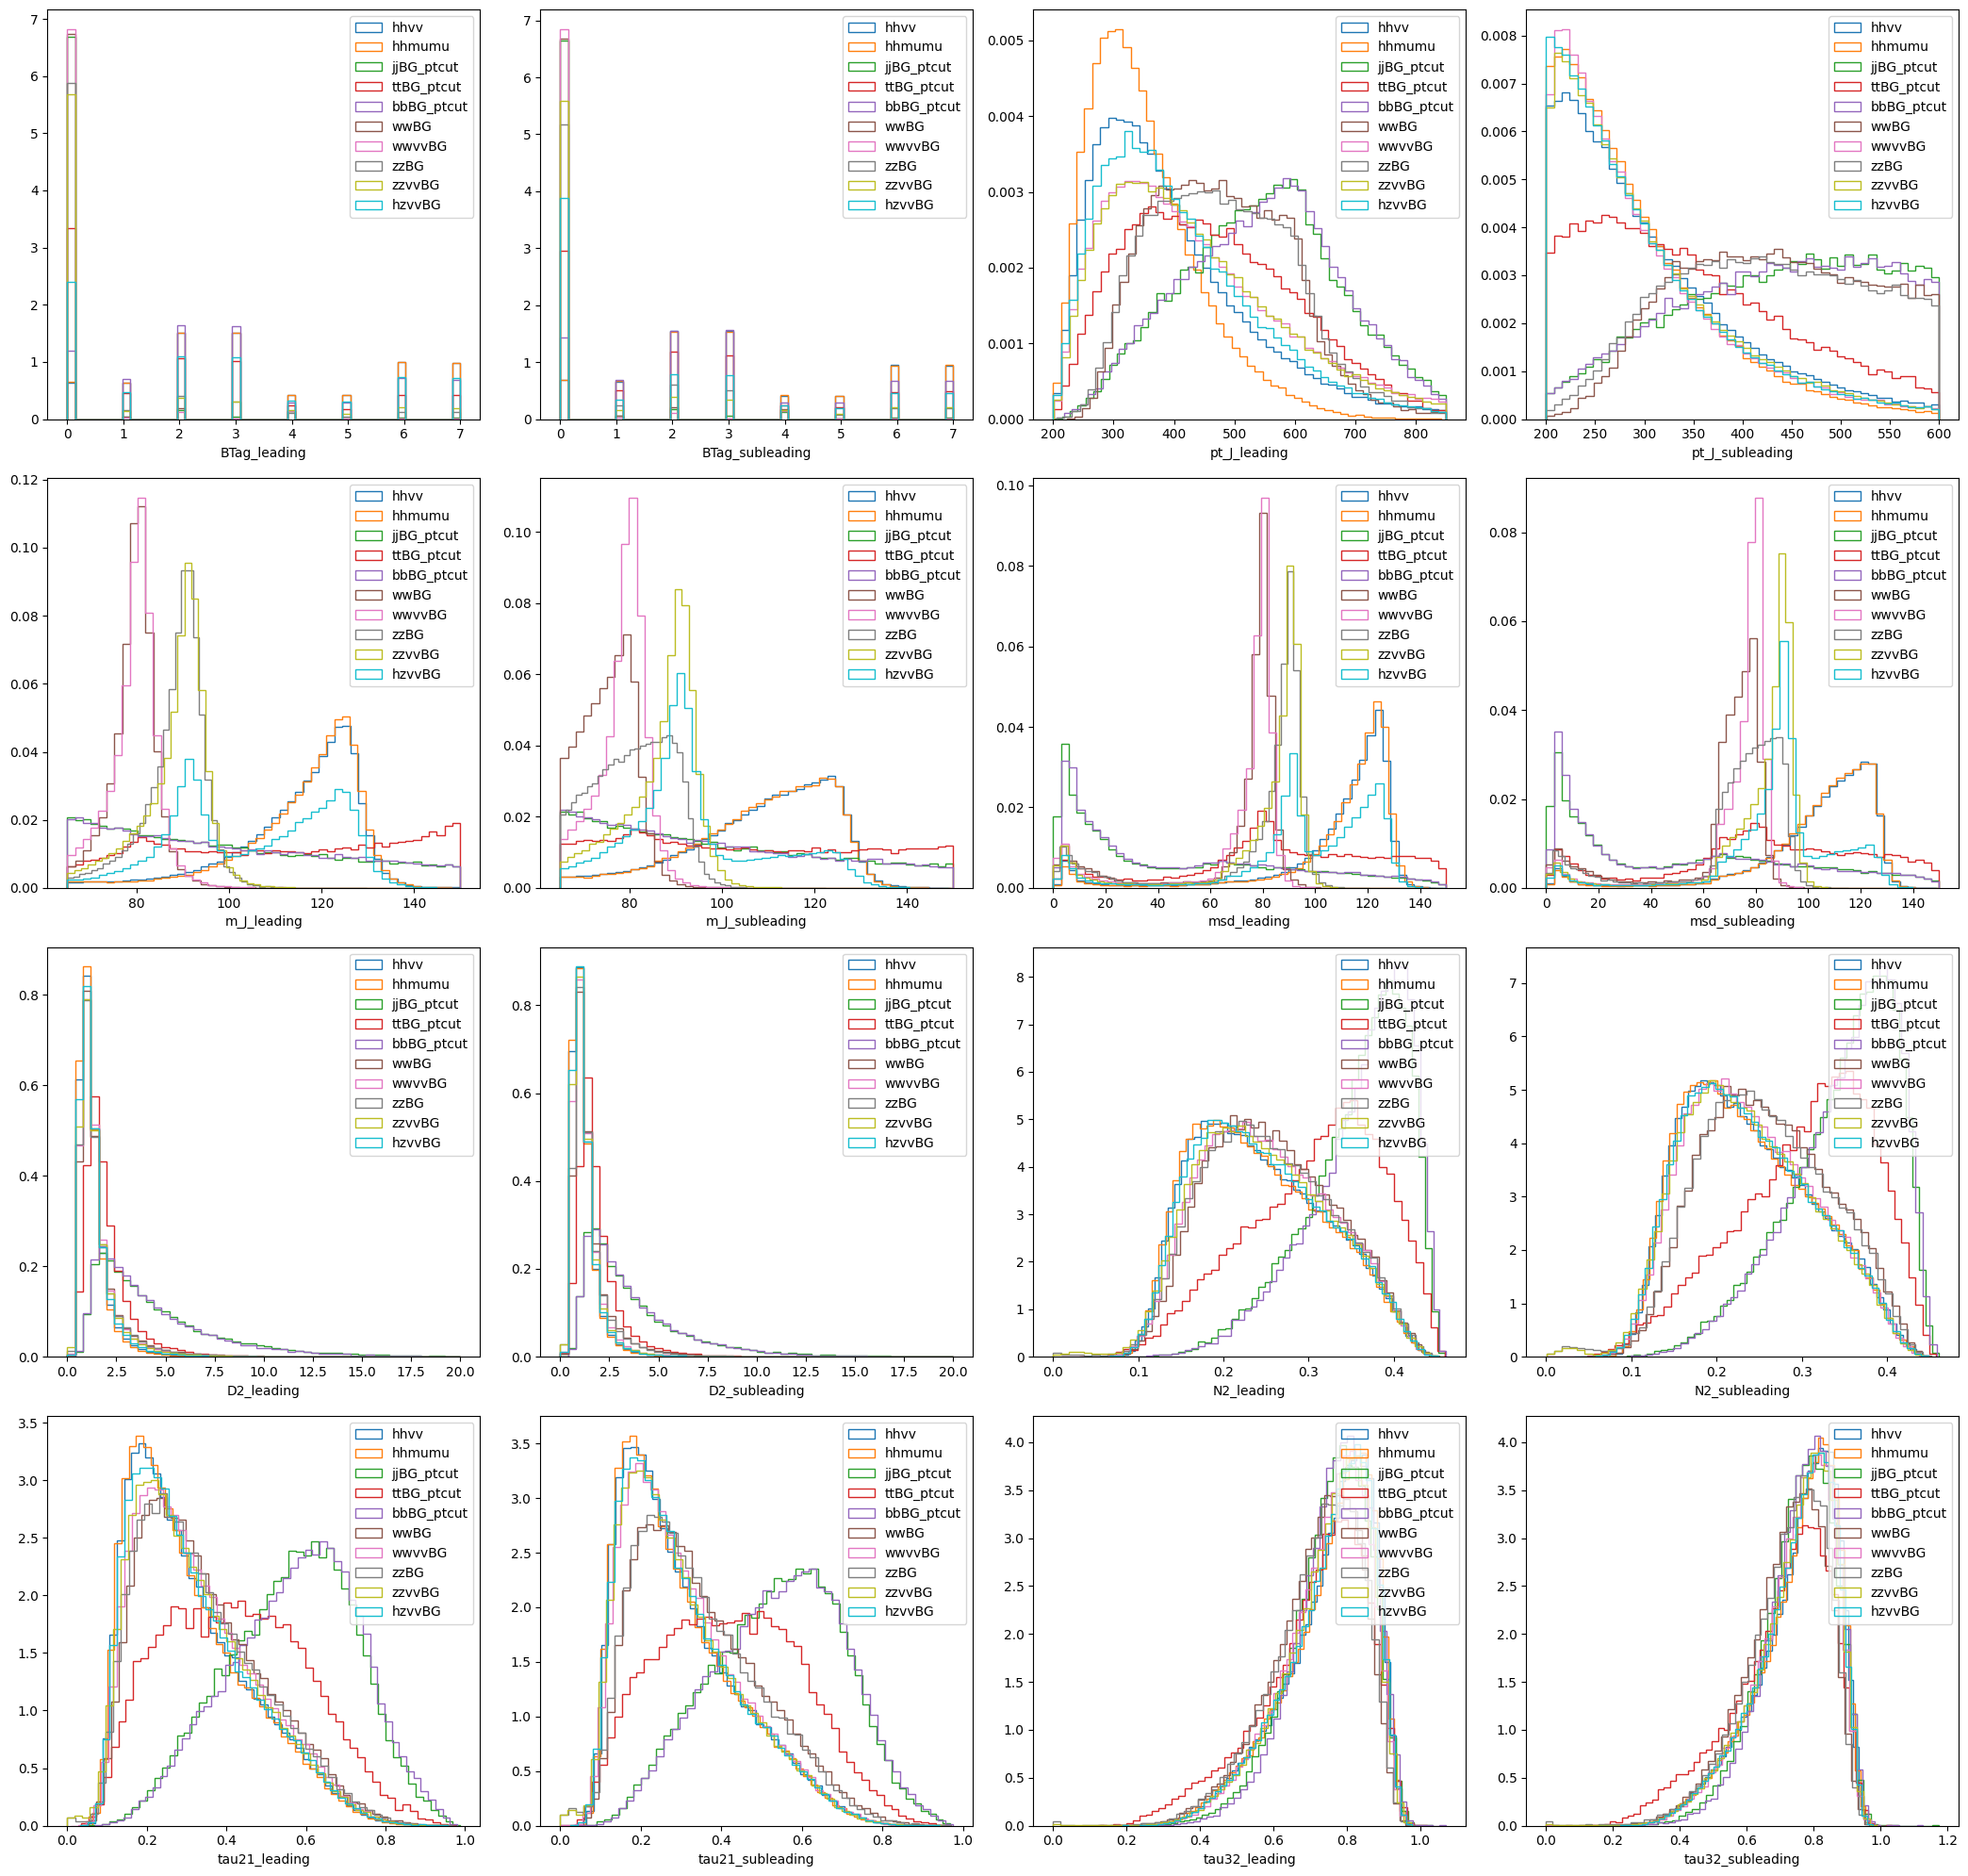

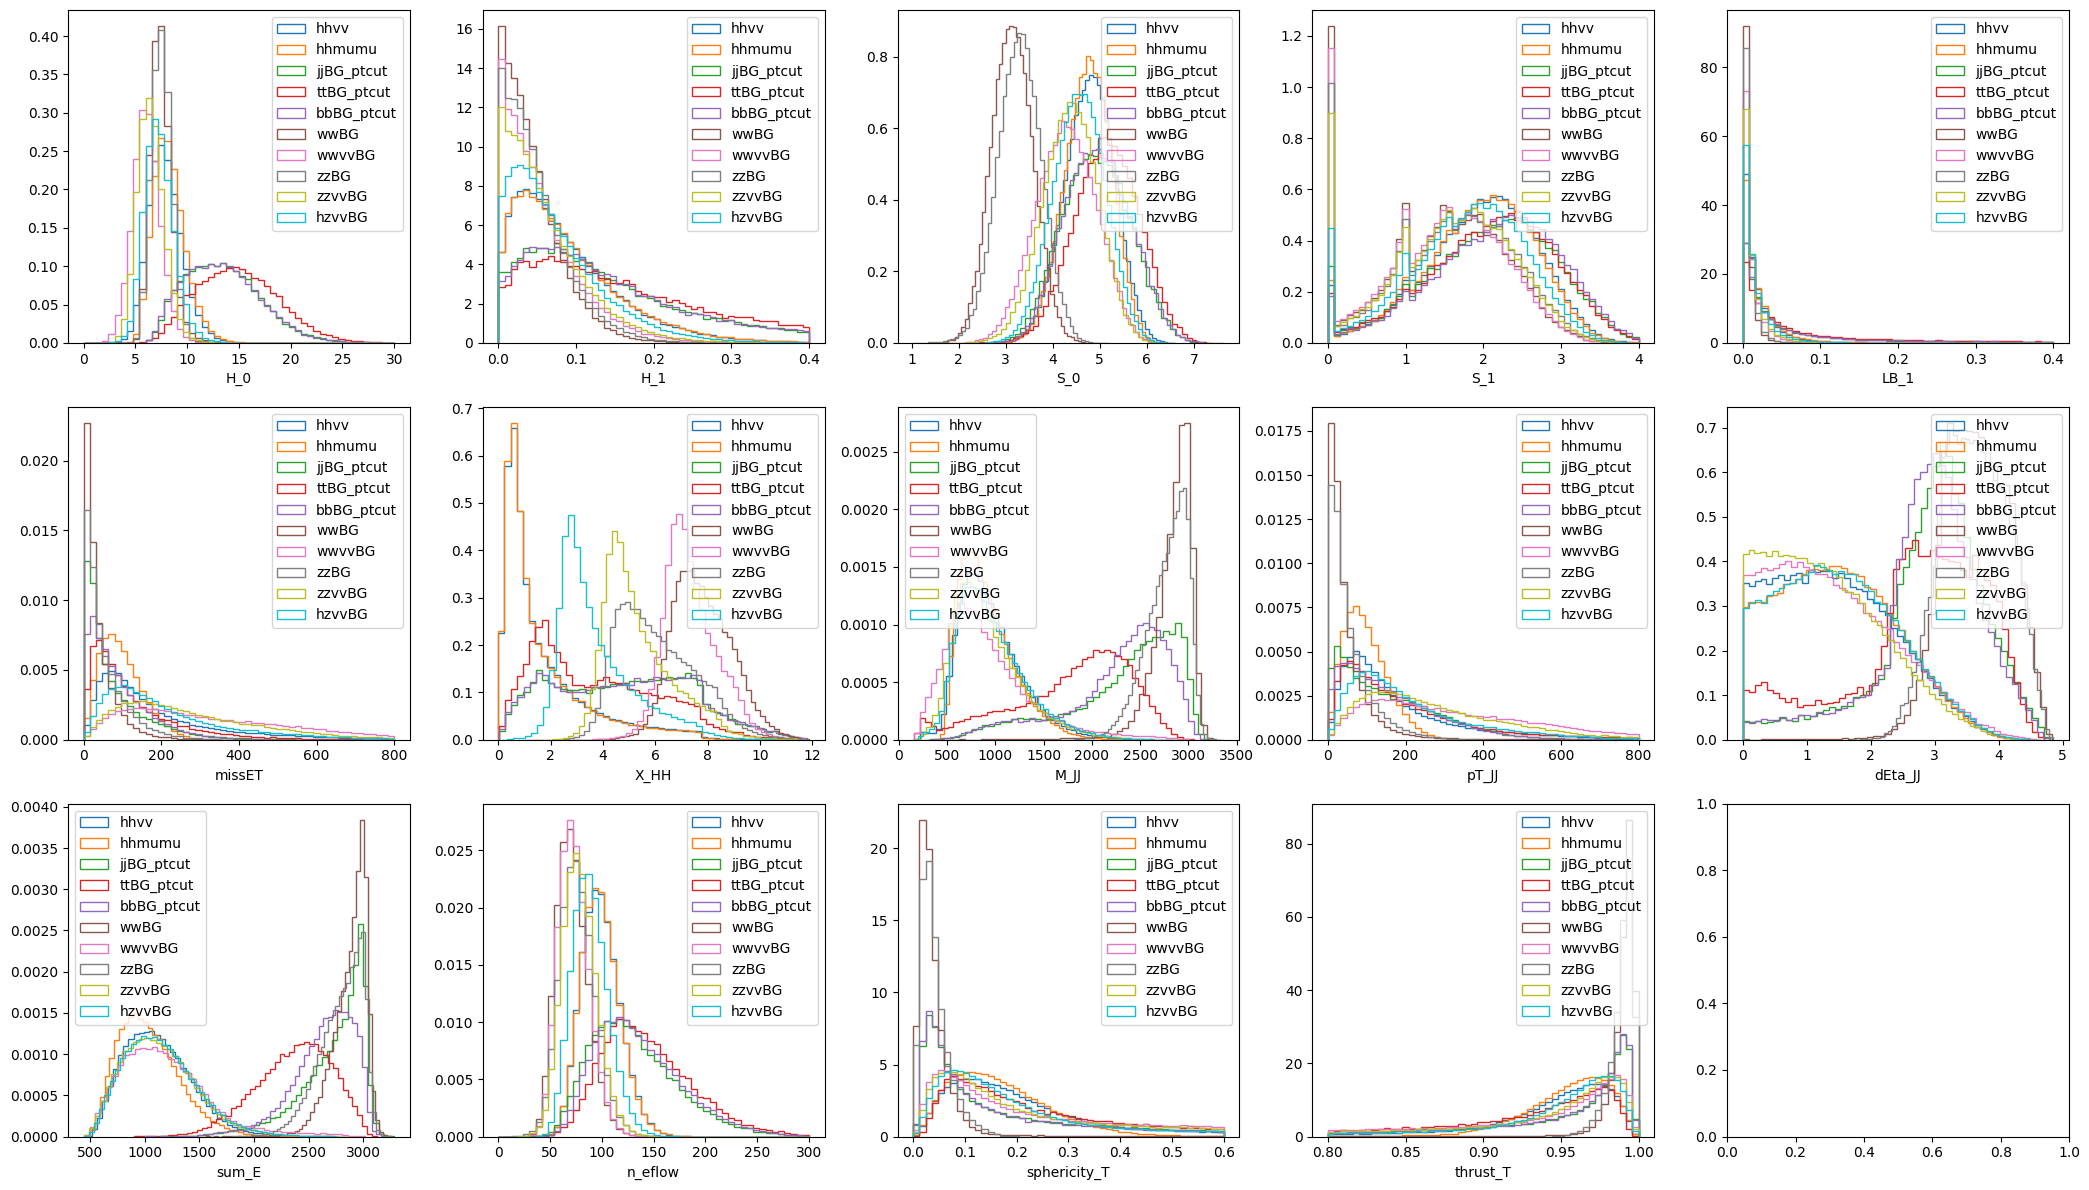

In [4]:
jet_plots = [('BTag_leading', None), ('BTag_subleading', None),
             ('pt_J_leading', None), ('pt_J_subleading', None), 
             ('m_J_leading', None), ('m_J_subleading', None), 
             ('msd_leading', None), ('msd_subleading', None),
             ('D2_leading', (0, 20)), ('D2_subleading', (0, 20)), 
             ('N2_leading', None), ('N2_subleading', None), 
             ('tau21_leading', None), ('tau21_subleading', None), 
             ('tau32_leading', None), ('tau32_subleading', None)]

fig, ax = plt.subplots(4, 4, figsize=(21, 20))
for i in range(4):
    for a, (k, rng) in zip(ax[i], jet_plots[i*4:i*4+4]):
        count = 0
        for process in processes:
            a.hist(HLdata[k][count:(count+event_num[process])], bins=50, range=rng, histtype='step', density=True, label=process)
            count += event_num[process]
        a.set_xlabel(k)
        a.legend()
plt.tight_layout(); plt.show()

event_plots = [('H_0', (0, 30)), ('H_1', (0, 0.4)), ('S_0', None), ('S_1', (0, 4)), ('LB_1', (0, 0.4)), 
               ('missET', (0, 800)), ('X_HH', None), ('M_JJ', None), ('pT_JJ', (0, 800)), ('dEta_JJ', None), 
               ('sum_E', None), ('n_eflow', (0, 300)), ('sphericity_T', (0, 0.6)), ('thrust_T', (0.8, 1))]
fig, ax = plt.subplots(3, 5, figsize=(21, 12))
for i in range(3):
    for a, (k, rng) in zip(ax[i], event_plots[i*5:i*5+5]):
        count = 0
        for process in processes:
            a.hist(HLdata[k][count:(count+event_num[process])], bins=50, range=rng, histtype='step', density=True, label=process)
            count += event_num[process]
        a.set_xlabel(k)
        a.legend()
plt.tight_layout(); plt.show()

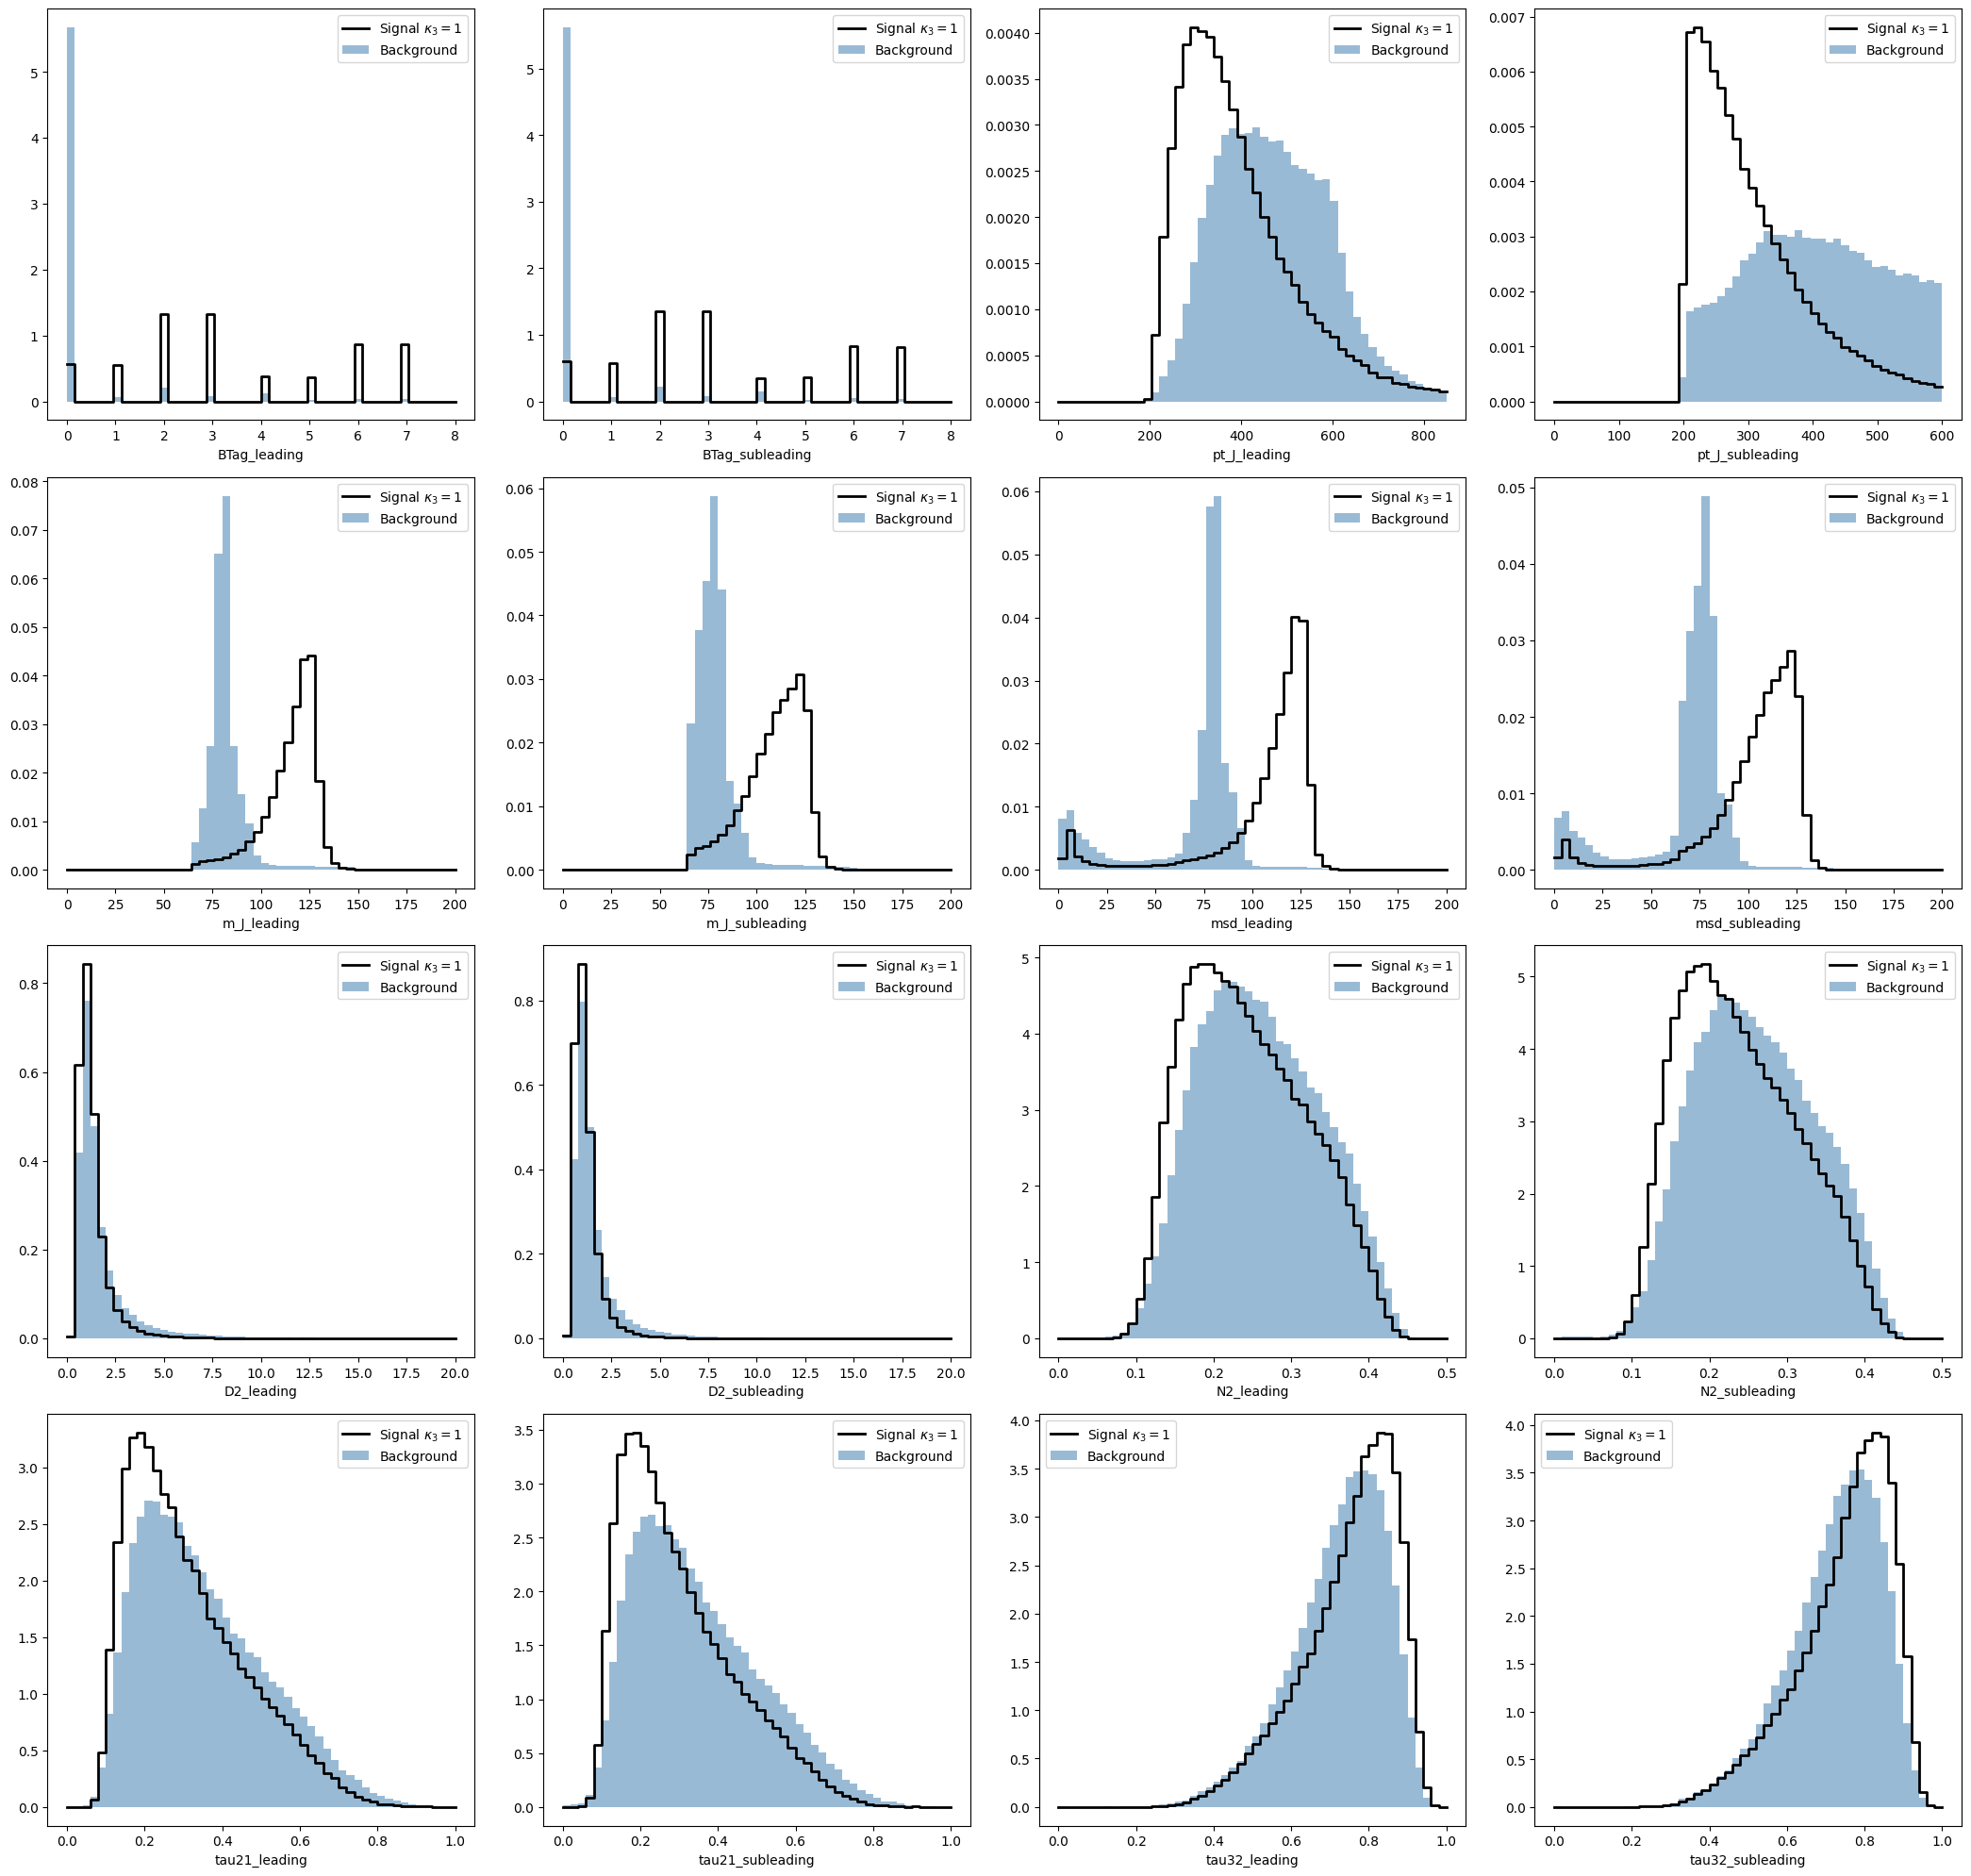

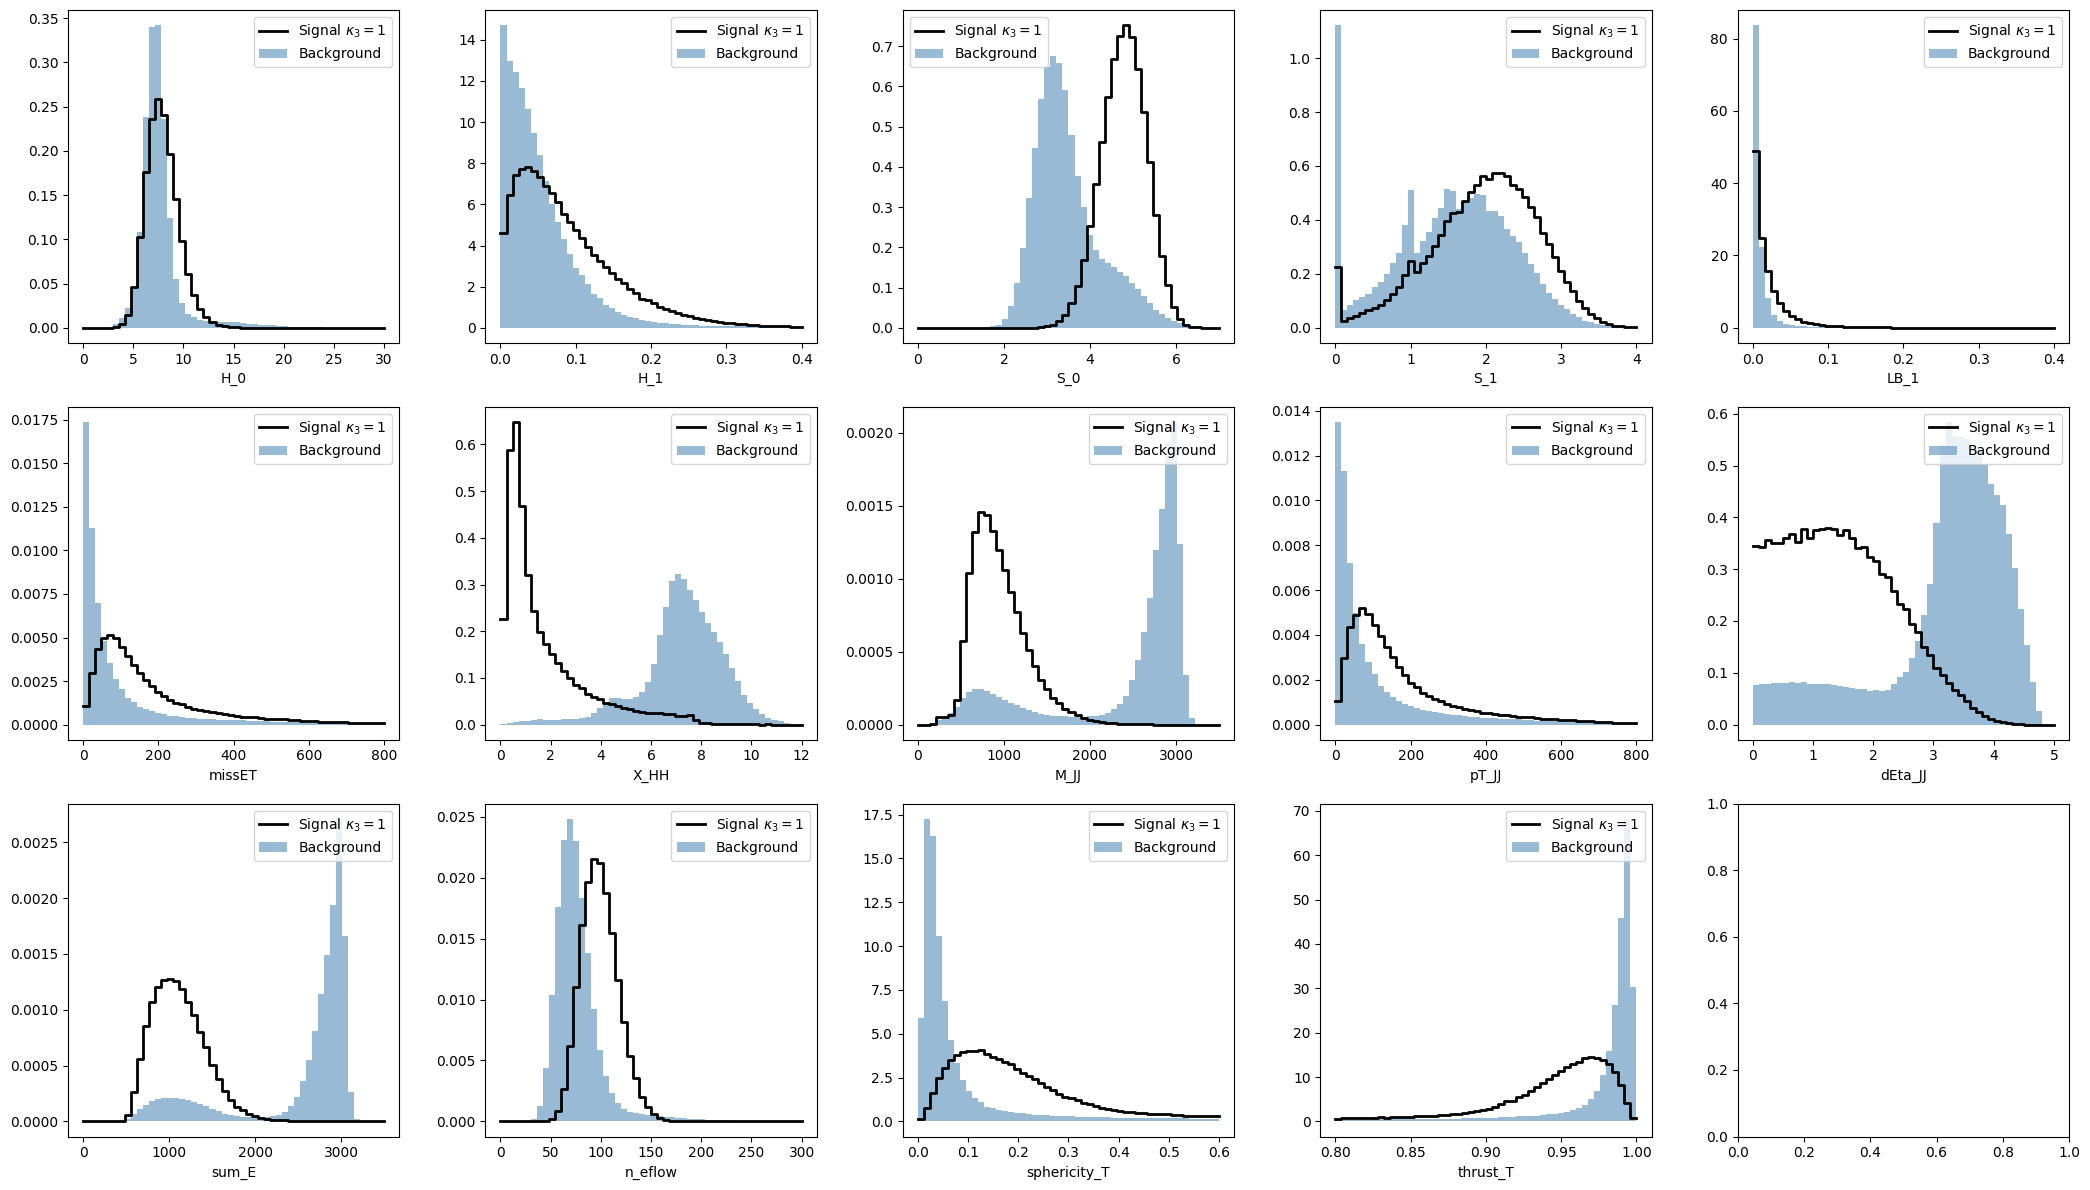

In [12]:
jet_plots = [('BTag_leading', (0, 8)), ('BTag_subleading', (0, 8)),
             ('pt_J_leading', (0, 850)), ('pt_J_subleading', (0, 600)), 
             ('m_J_leading', (0, 200)), ('m_J_subleading', (0, 200)), 
             ('msd_leading', (0, 200)), ('msd_subleading', (0, 200)),
             ('D2_leading', (0, 20)), ('D2_subleading', (0, 20)), 
             ('N2_leading', (0, 0.5)), ('N2_subleading', (0, 0.5)), 
             ('tau21_leading', (0, 1)), ('tau21_subleading', (0, 1)), 
             ('tau32_leading', (0, 1)), ('tau32_subleading', (0, 1))]

BR_hbb = 0.5824
Xsection = [5.6572451e-02*BR_hbb*BR_hbb, 4.758146e-03*BR_hbb*BR_hbb, 1.345440e+01, 4.423700e+00, 2.325600e+00, 1.507183e+02, 1.223107e+01, 9.617100e+00, 6.469436e+00, 1.27619546e+00*BR_hbb]     ### unit: fb
simulation_num = 500000

sig_event_num = event_num['hhvv']+event_num['hhmumu']
bg_event_num = len(HLdata) - sig_event_num

sig_weight = [np.full(event_num[process], Xsection[processes.index(process)]) for process in ['hhvv', 'hhmumu']]
bg_weight = [np.full(event_num[process], Xsection[processes.index(process)]) for process in ["jjBG_ptcut", "ttBG_ptcut", "bbBG_ptcut", "wwBG", "wwvvBG", "zzBG", "zzvvBG", "hzvvBG"]]


sig_weight_total = np.concatenate(sig_weight)
bg_weight_total = np.concatenate(bg_weight)


fig, ax = plt.subplots(4, 4, figsize=(21, 20))
for i in range(4):
    for a, (k, rng) in zip(ax[i], jet_plots[i*4:i*4+4]):
        
        sig_data_total = HLdata[k][0:sig_event_num]
        bg_data_total = HLdata[k][sig_event_num:]
        
        h_bg, _  = np.histogram(bg_data_total,  bins=50, range=rng, weights=bg_weight_total, density=True)
        h_sig, _ = np.histogram(sig_data_total, bins=50, range=rng, weights=sig_weight_total, density=True)
        
        edges = np.linspace(rng[0], rng[1], 51)
        
        a.fill_between(edges, np.r_[h_bg, h_bg[-1]], step='post',
                color='steelblue', alpha=0.55, linewidth=0,
                label='Background', zorder=1)
        a.step(edges, np.r_[h_sig, h_sig[-1]], where='post',
            color='k', lw=2, label=r'Signal $\kappa_3 = 1$', zorder=2)
        
        a.set_xlabel(k)
        a.legend()
plt.tight_layout(); plt.show()

event_plots = [('H_0', (0, 30)), ('H_1', (0, 0.4)), ('S_0', (0, 7)), ('S_1', (0, 4)), ('LB_1', (0, 0.4)), 
               ('missET', (0, 800)), ('X_HH', (0, 12)), ('M_JJ', (0, 3500)), ('pT_JJ', (0, 800)), ('dEta_JJ', (0, 5)), 
               ('sum_E', (0, 3500)), ('n_eflow', (0, 300)), ('sphericity_T', (0, 0.6)), ('thrust_T', (0.8, 1))]
fig, ax = plt.subplots(3, 5, figsize=(21, 12))
for i in range(3):
    for a, (k, rng) in zip(ax[i], event_plots[i*5:i*5+5]):
        
        sig_data_total = HLdata[k][0:sig_event_num]
        bg_data_total = HLdata[k][sig_event_num:]
        
        h_bg, _  = np.histogram(bg_data_total,  bins=50, range=rng, weights=bg_weight_total, density=True)
        h_sig, _ = np.histogram(sig_data_total, bins=50, range=rng, weights=sig_weight_total, density=True)
        
        edges = np.linspace(rng[0], rng[1], 51)
        
        a.fill_between(edges, np.r_[h_bg, h_bg[-1]], step='post',
                color='steelblue', alpha=0.55, linewidth=0,
                label='Background', zorder=1)
        a.step(edges, np.r_[h_sig, h_sig[-1]], where='post',
            color='k', lw=2, label=r'Signal $\kappa_3 = 1$', zorder=2)
        
        a.set_xlabel(k)
        a.legend()
plt.tight_layout(); plt.show()

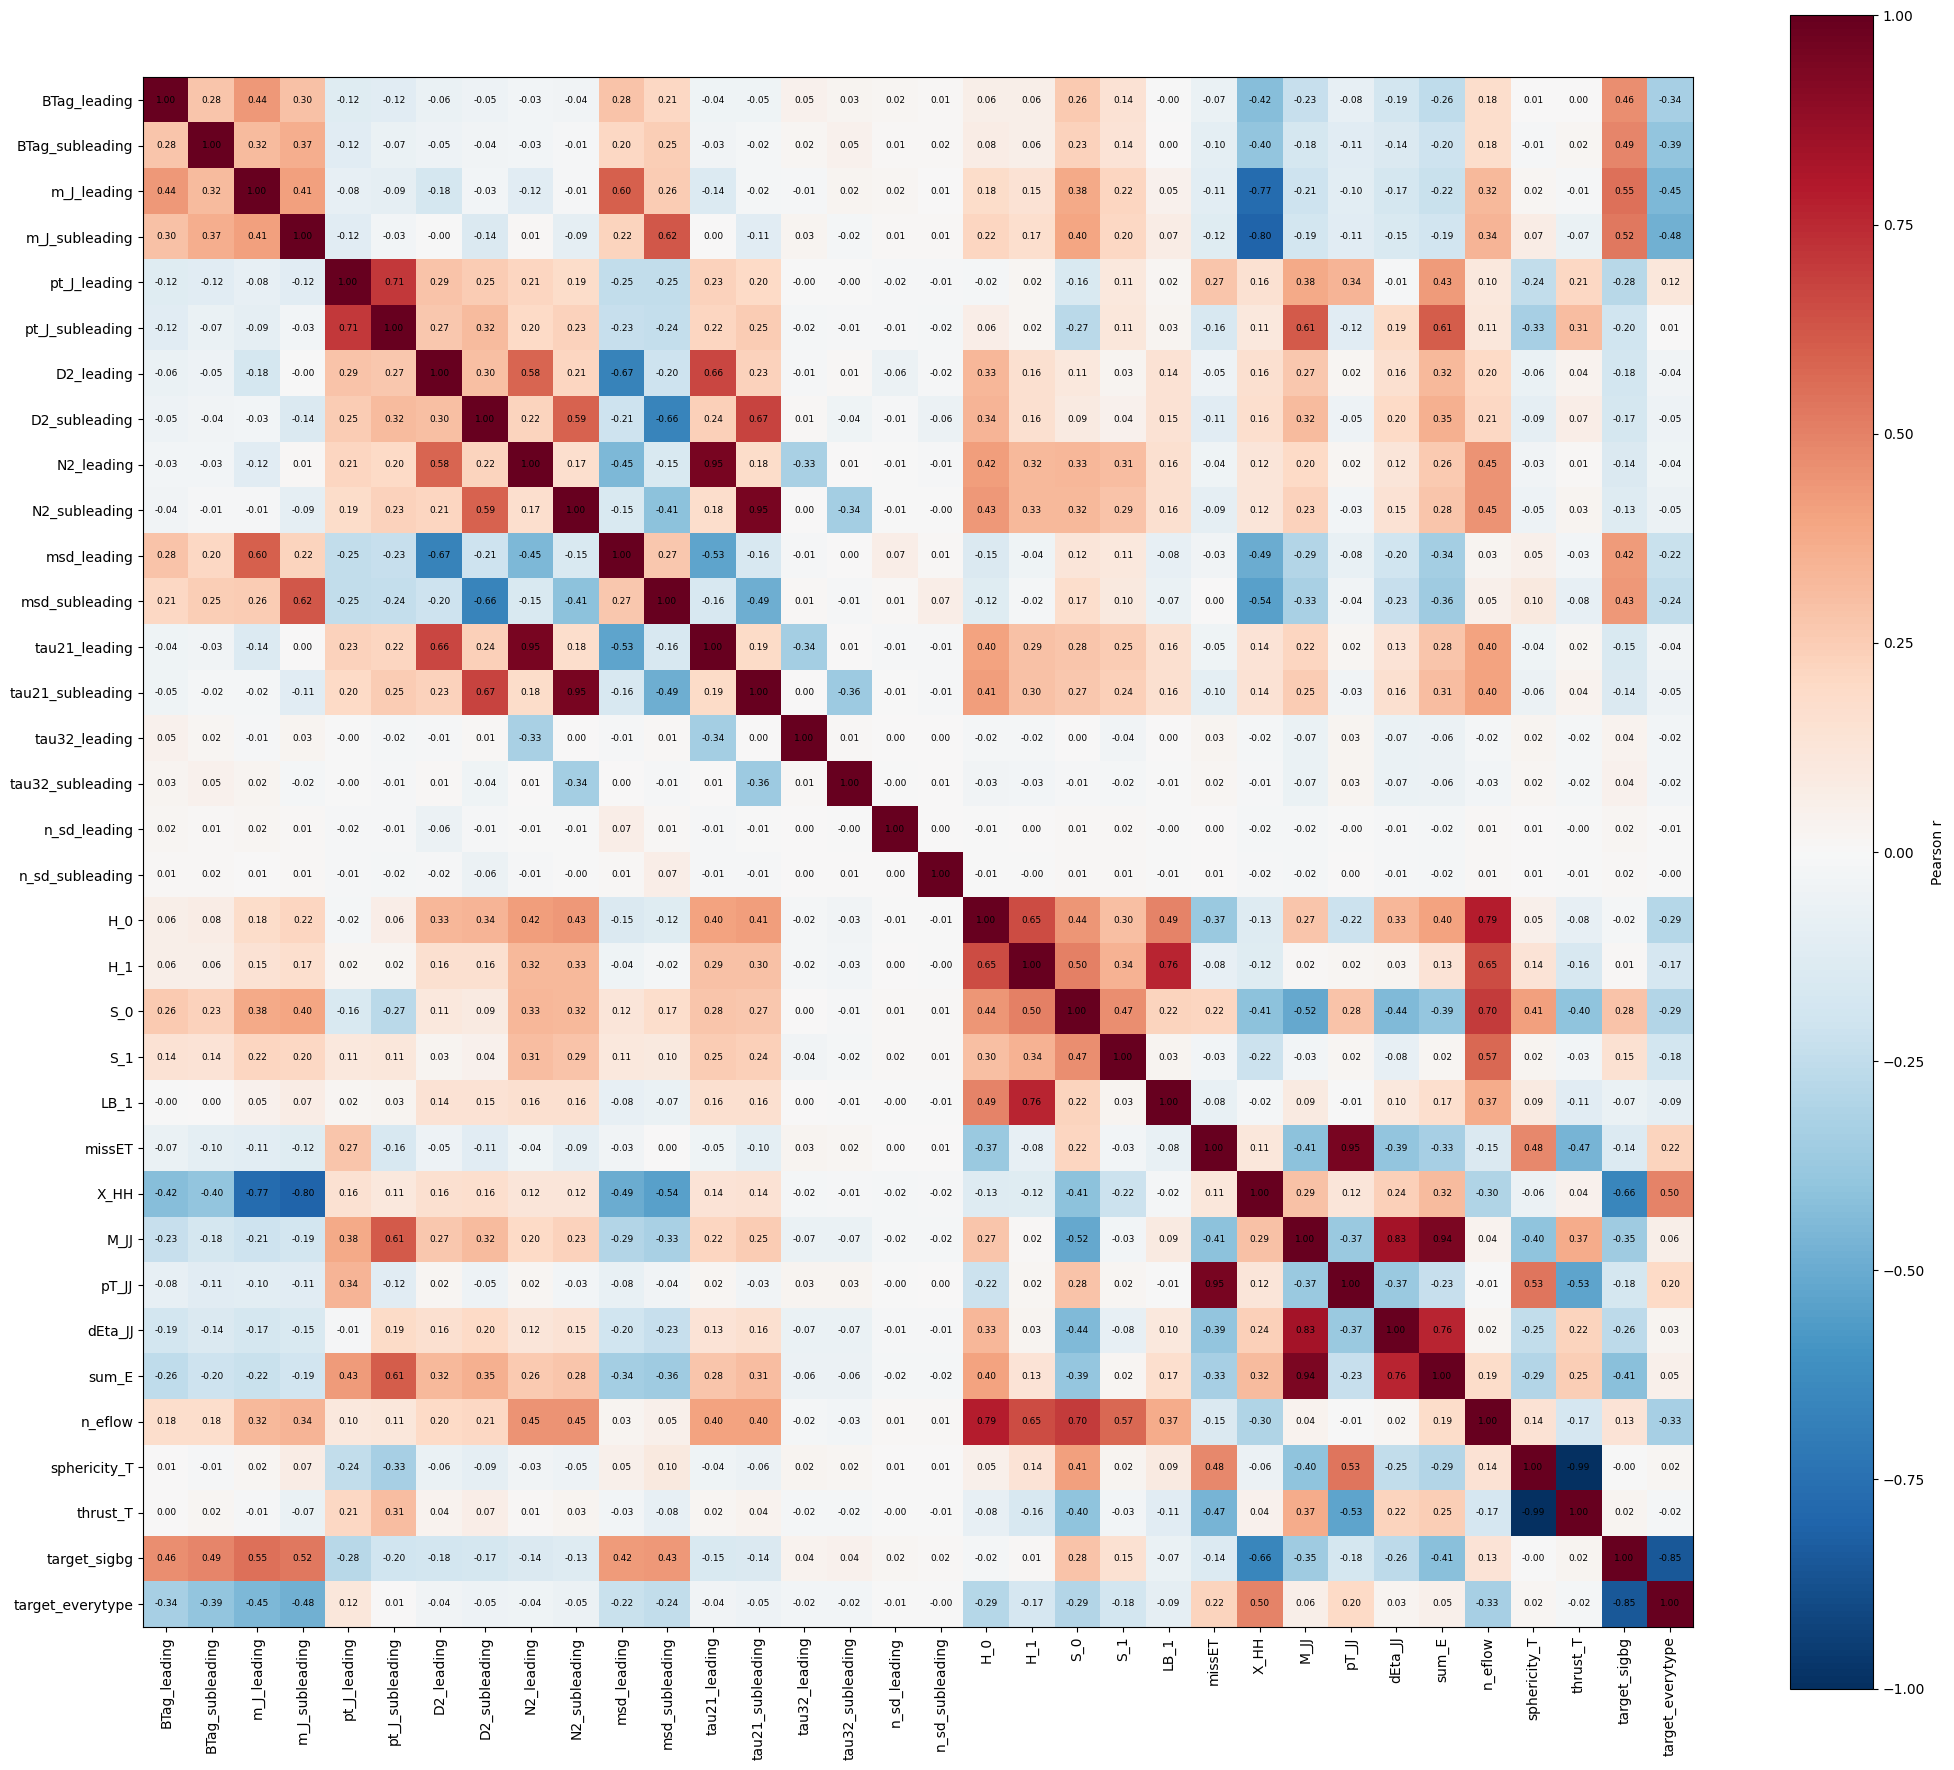

In [7]:
C = HLdata[features].corr()

fig, ax = plt.subplots(figsize=(21, 18))
im = ax.imshow(C, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(features))); ax.set_xticklabels(features, rotation=90)
ax.set_yticks(range(len(features))); ax.set_yticklabels(features)
for i in range(len(features)):
    for j in range(len(features)):
        ax.text(j, i, f'{C.iloc[i, j]:.2f}', ha='center', va='center', fontsize=6.5)
fig.colorbar(im, label='Pearson r'); plt.tight_layout(); plt.show()